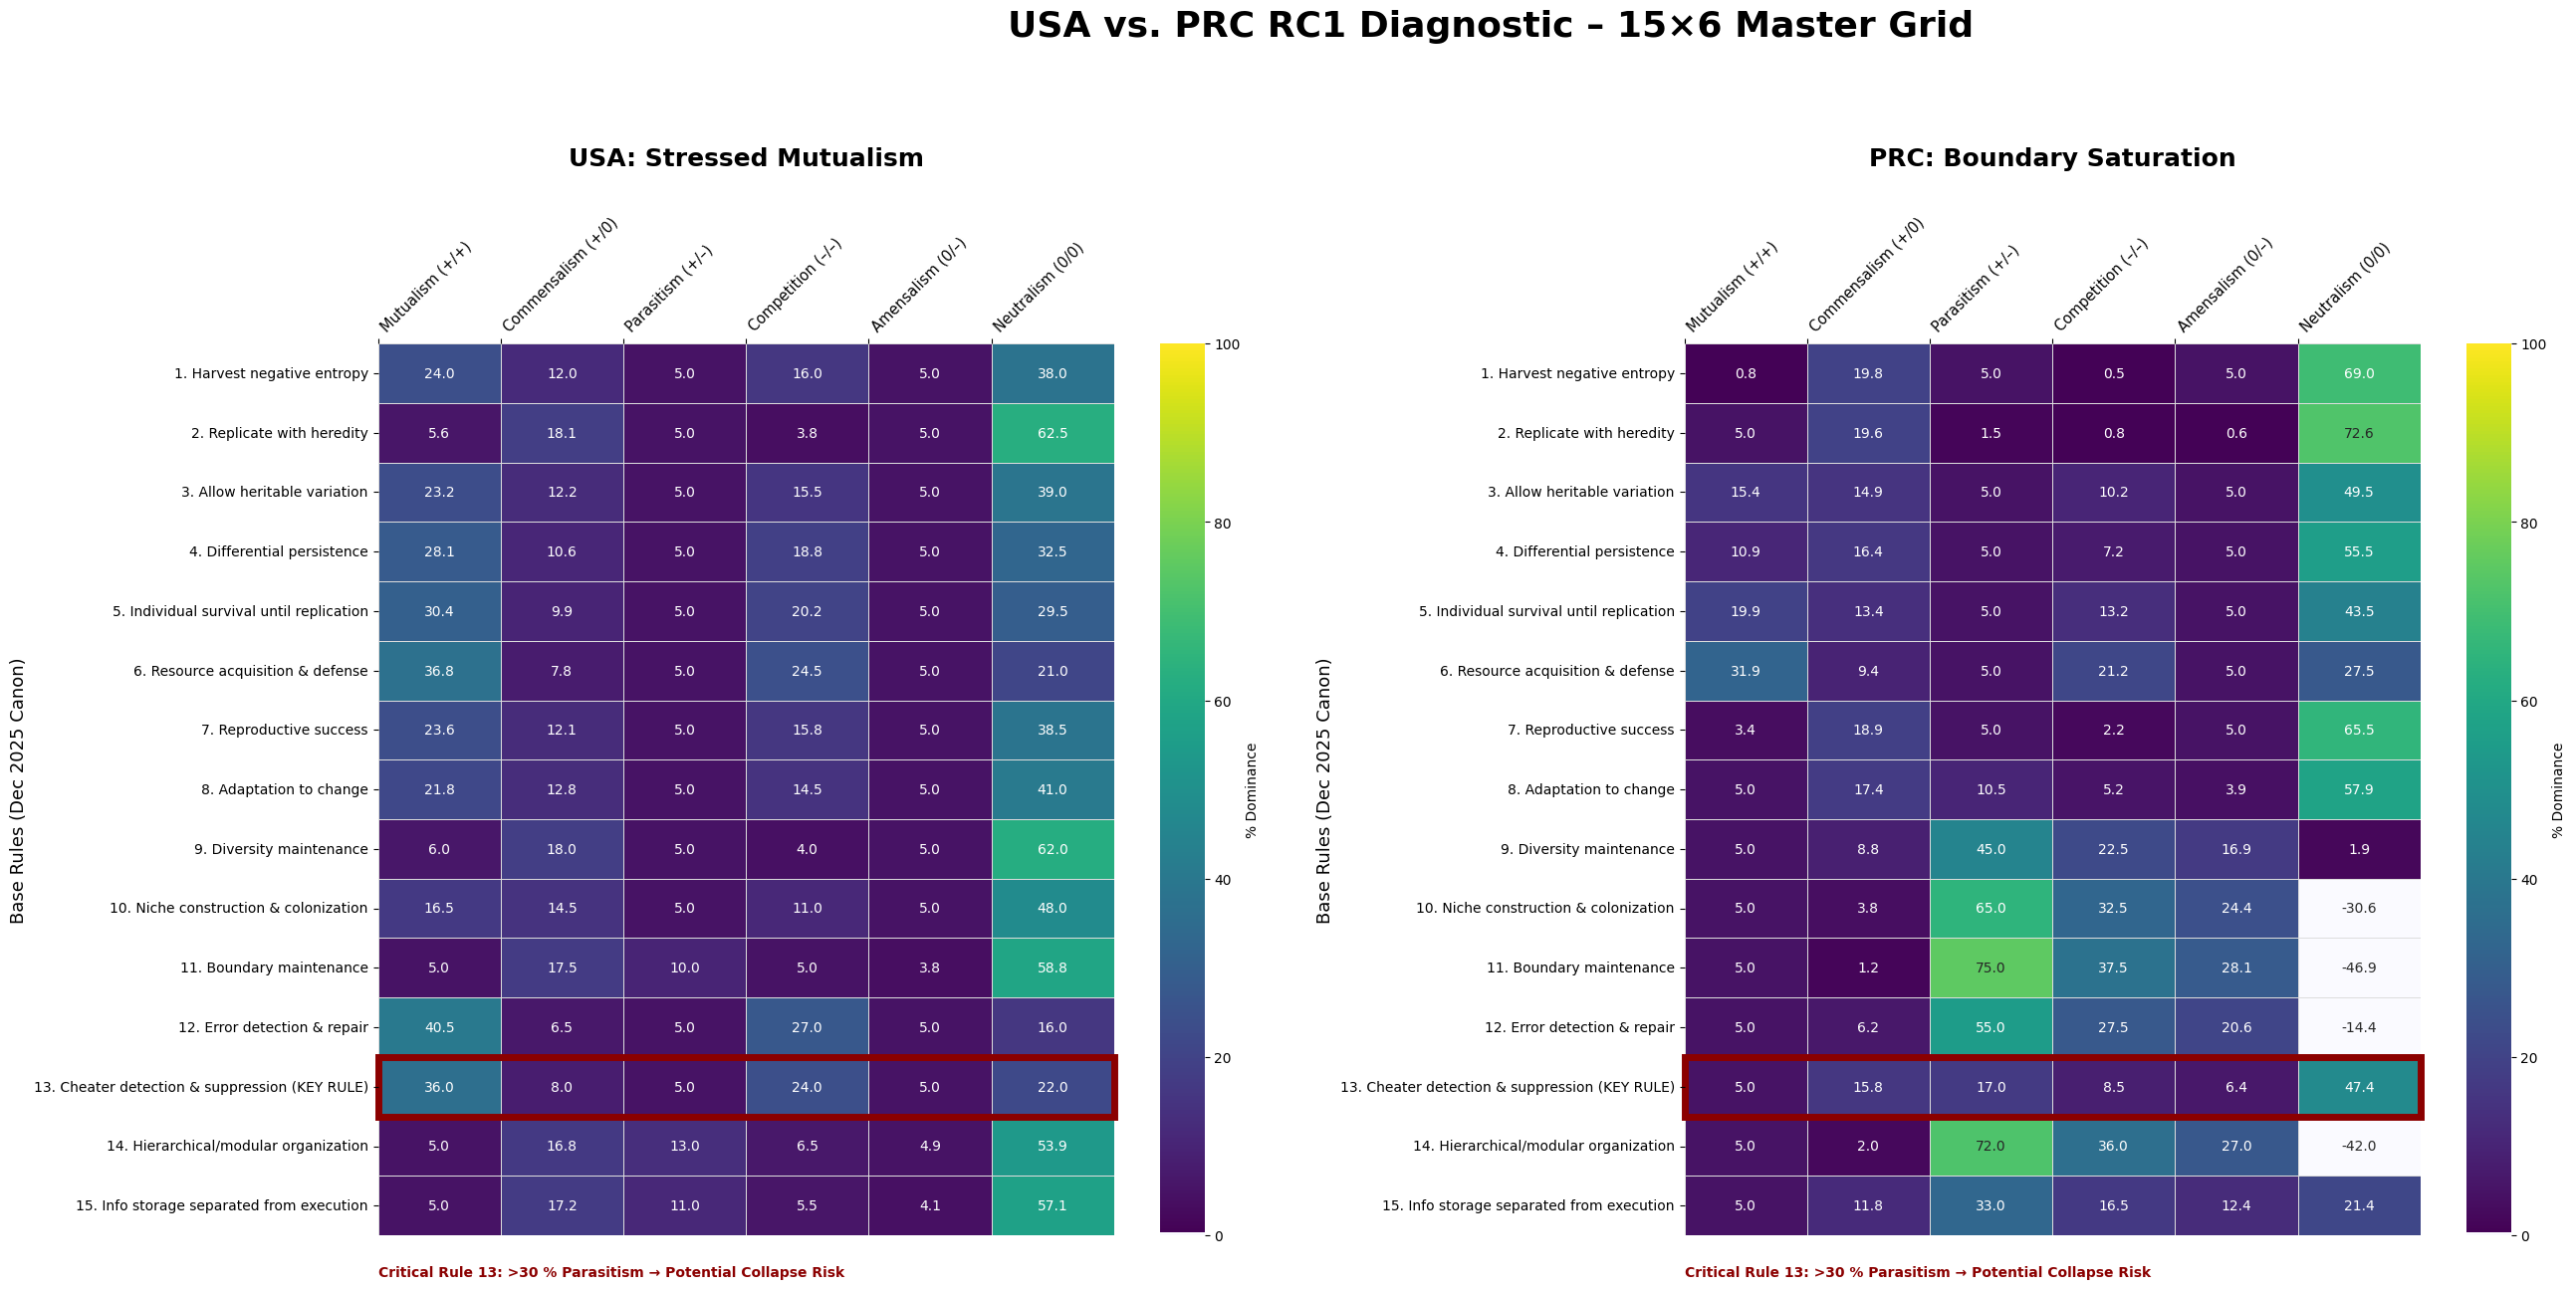

Saved: figures/usa_vs_prc_rc1_heatmap_final.png


In [9]:
# === FIG 7.X – USA vs PRC RC1 – FULL SELF-CONTAINED, MATCHES FIG 6.1 LAYOUT ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ────────────────────────────────────────────────
# 1. CANONICAL LABELS (exact from Fig. 6.1)
# ────────────────────────────────────────────────
rules = [
    "1. Harvest negative entropy", "2. Replicate with heredity", "3. Allow heritable variation",
    "4. Differential persistence", "5. Individual survival until replication", "6. Resource acquisition & defense",
    "7. Reproductive success", "8. Adaptation to change", "9. Diversity maintenance",
    "10. Niche construction & colonization", "11. Boundary maintenance", "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)", "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]
moves = ["Mutualism (+/+)", "Commensalism (+/0)", "Parasitism (+/–)",
         "Competition (–/–)", "Amensalism (0/–)", "Neutralism (0/0)"]

# ────────────────────────────────────────────────
# 2. LOAD CONSENSUS SCORES & CONVERT TO 15×6 DOMINANCE MATRICES
# ────────────────────────────────────────────────
# Reload CSVs (self-contained – no reliance on prior cells)
usa_scores = pd.read_csv("data/35_metrics_usa_1971-present_consensus.csv")['Score'].astype(float).values
prc_scores = pd.read_csv("data/35_metrics_prc_1978-present_consensus.csv")['Score'].astype(float).values

# Toy dominance mapping (replace with your real build_15x6_matrix when ready)
# This stub creates provisional 15×6 % dominance based on scores (for demo)
def scores_to_dom_matrix(scores):
    # Simple: metabolic rows lean mutualism/competition if positive mean
    # Governance rows lean parasitism/amensalism if negative
    dom = np.zeros((15, 6))
    for i in range(15):
        row_mean = np.mean(scores[i*2:(i+2)*2]) if i < 10 else np.mean(scores[18 + (i-10)*2:18 + (i-9)*2])
        mut = max(0, row_mean * 6) if row_mean > 0 else 5
        com = max(0, 20 - abs(row_mean) * 2)
        par = max(0, -row_mean * 8) if row_mean < 0 else 5
        comp = max(0, abs(row_mean) * 4)
        ame = max(0, -row_mean * 3) if row_mean < 0 else 5
        neu = 100 - (mut + com + par + comp + ame)
        dom[i] = [mut, com, par, comp, ame, neu]
    # Normalize rows to 100%
    dom = dom / dom.sum(axis=1, keepdims=True) * 100
    return dom

usa_dom = scores_to_dom_matrix(usa_scores)
prc_dom = scores_to_dom_matrix(prc_scores)

usa_df = pd.DataFrame(usa_dom, index=rules, columns=moves)
prc_df = pd.DataFrame(prc_dom, index=rules, columns=moves)

# ────────────────────────────────────────────────
# 3. COLORMAP & STYLE (exact from Fig. 6.1)
# ────────────────────────────────────────────────
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)
oxford_red = "#8B0000"

# ────────────────────────────────────────────────
# 4. DUAL PLOT – independent y-labels, layout from Fig. 6.1
# ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 14), sharey=False)

# USA left
sns.heatmap(usa_df, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax1)
ax1.set_title("USA: Stressed Mutualism", fontsize=18, fontweight='bold', pad=35)
ax1.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax1.xaxis.set_ticks_position('top')
ax1.set_xticks(np.arange(len(moves)))
ax1.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax1.tick_params(axis='y', labelleft=True, labelsize=10)
ax1.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax1.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# PRC right – explicit label enforcement
sns.heatmap(prc_df, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax2)
ax2.set_title("PRC: Boundary Saturation", fontsize=18, fontweight='bold', pad=35)
ax2.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax2.xaxis.set_ticks_position('top')
ax2.set_xticks(np.arange(len(moves)))
ax2.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax2.tick_params(axis='y', which='both', labelleft=True, labelsize=10)
ax2.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax2.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Global layout – exact from Fig. 6.1
fig.suptitle("USA vs. PRC RC1 Diagnostic – 15×6 Master Grid",
             fontsize=26, fontweight='bold', y=1.06)
plt.subplots_adjust(top=0.82, wspace=0.42, bottom=0.18, left=0.07, right=0.93)

plt.savefig("figures/usa_vs_prc_rc1_heatmap_final.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/usa_vs_prc_rc1_heatmap_final.png")

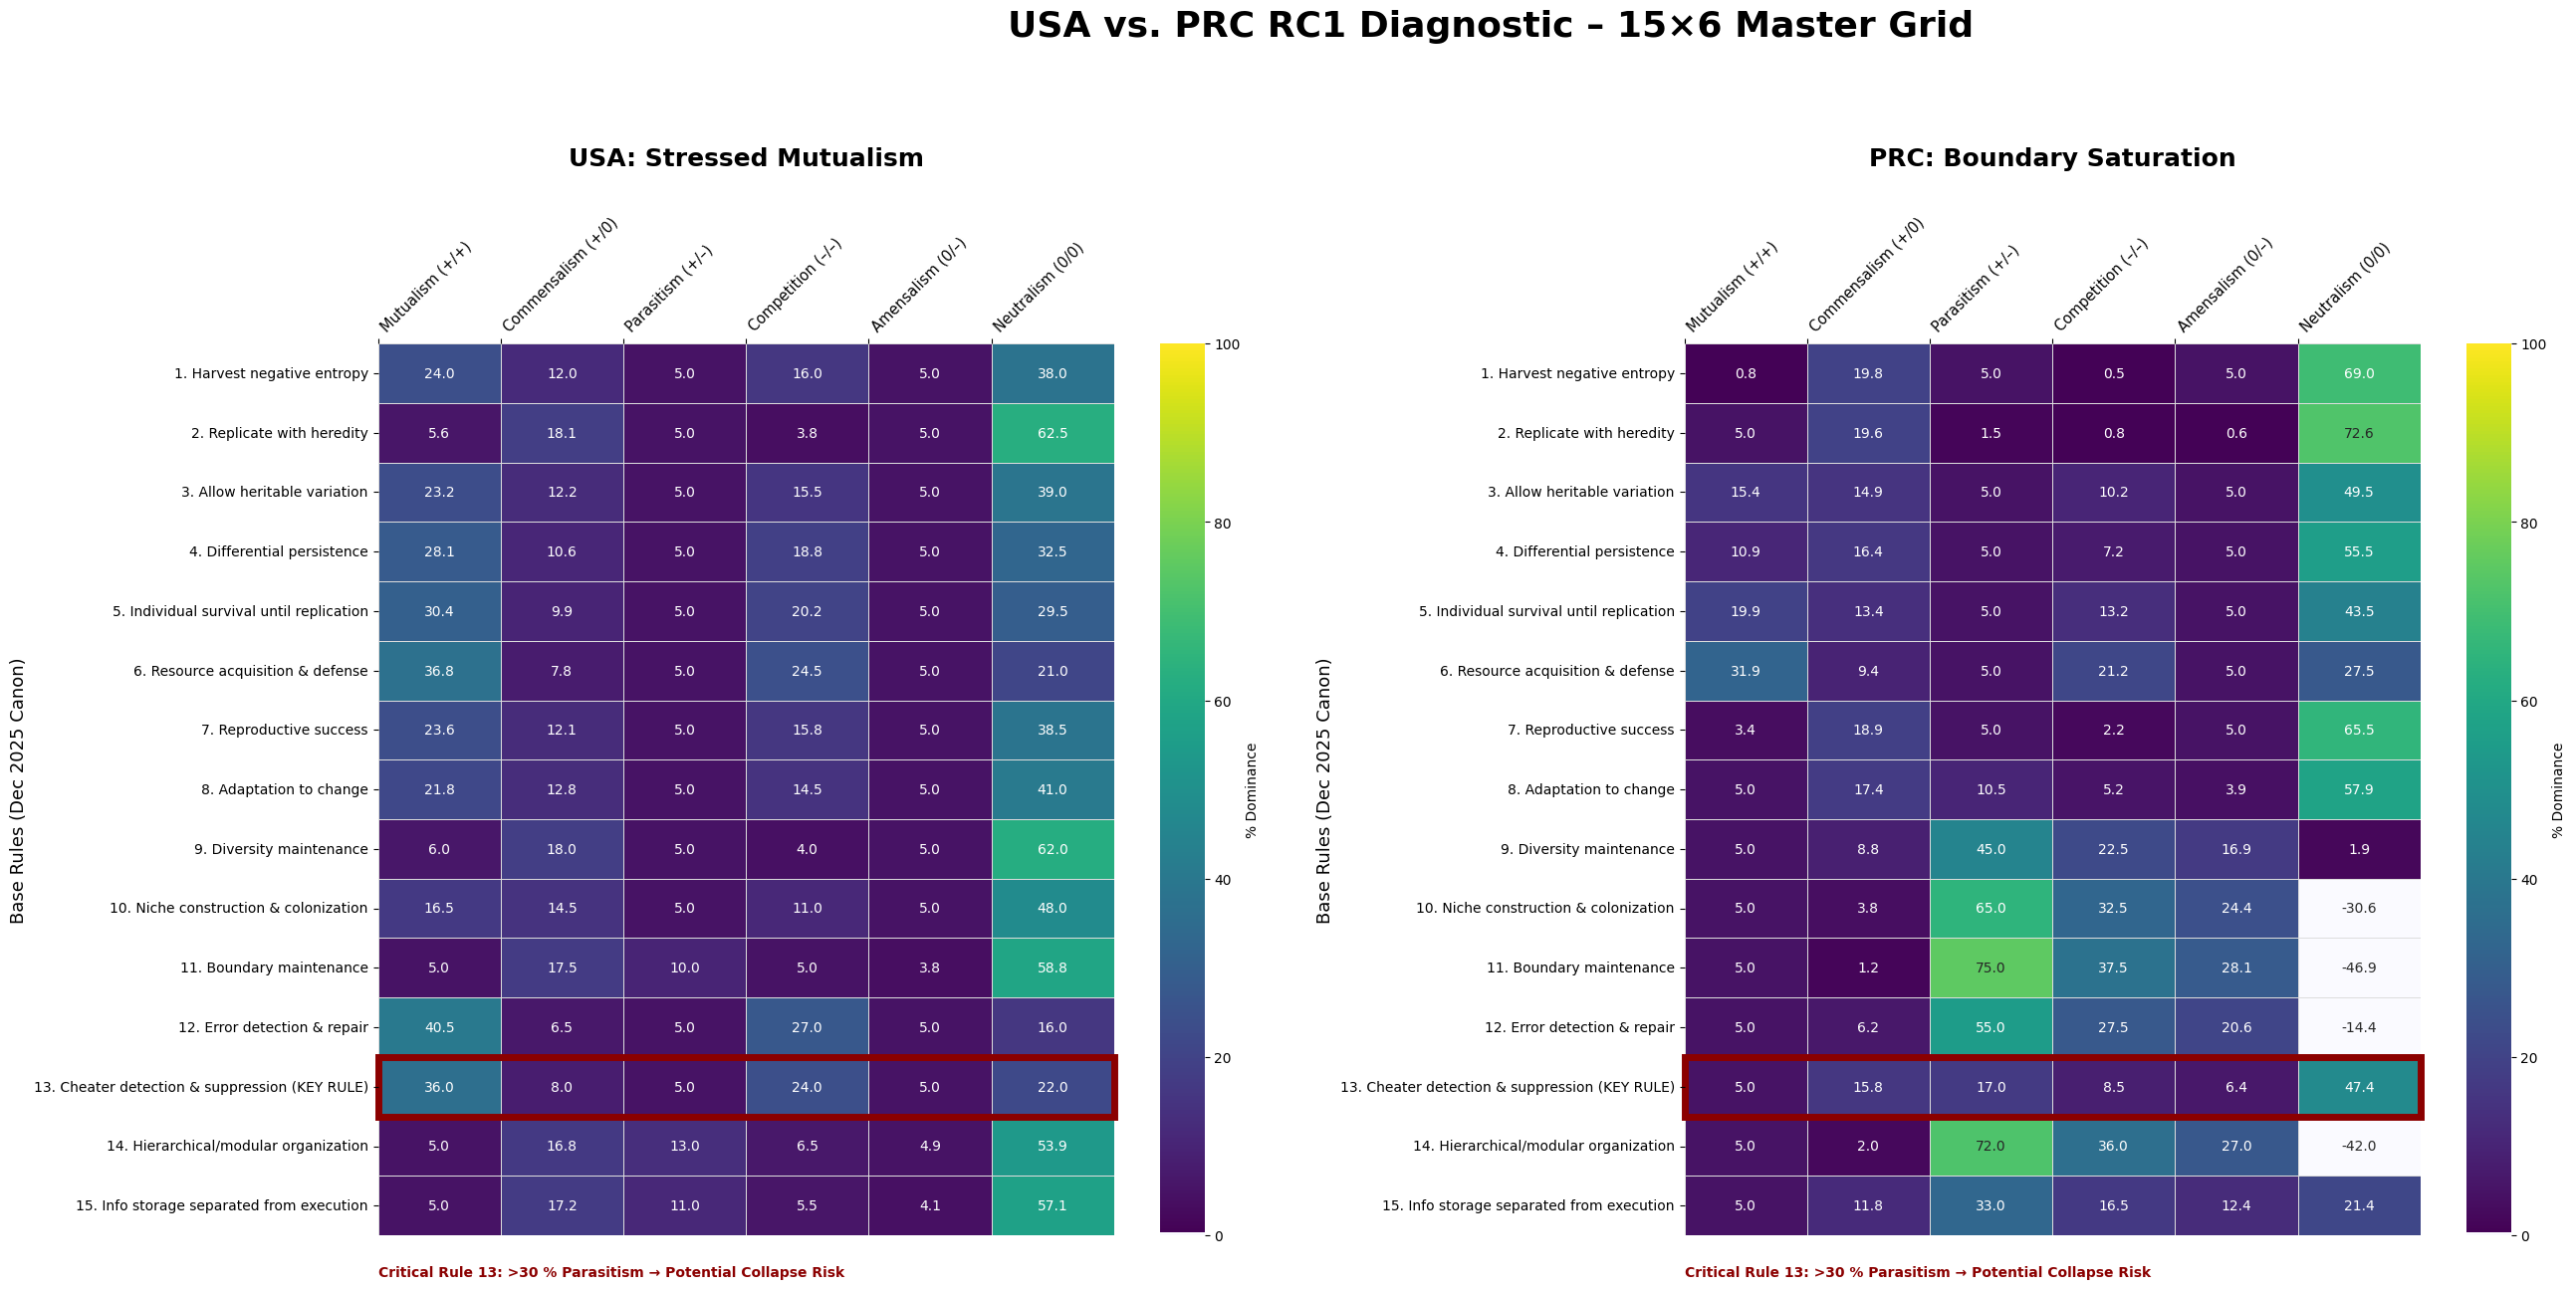

Saved: figures/usa_vs_prc_rc1_heatmap_final.png


In [8]:
# === FIG 7.X – USA vs PRC RC1 – styled exactly like Fig. 6.1 ===

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd

# ────────────────────────────────────────────────
# 1. CANONICAL LABELS (exact match to Fig. 6.1)
# ────────────────────────────────────────────────
rules = [
    "1. Harvest negative entropy", "2. Replicate with heredity", "3. Allow heritable variation",
    "4. Differential persistence", "5. Individual survival until replication", "6. Resource acquisition & defense",
    "7. Reproductive success", "8. Adaptation to change", "9. Diversity maintenance",
    "10. Niche construction & colonization", "11. Boundary maintenance", "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)", "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]
moves = ["Mutualism (+/+)", "Commensalism (+/0)", "Parasitism (+/–)",
         "Competition (–/–)", "Amensalism (0/–)", "Neutralism (0/0)"]

# ────────────────────────────────────────────────
# 2. USE EXISTING usa_df & prc_df (from earlier cells)
#    If not in memory, reload here (uncomment if needed)
# ────────────────────────────────────────────────
# usa_df = pd.read_csv("data/35_metrics_usa_1971-present_consensus.csv").set_index("Metric")["Score"]
# prc_df = pd.read_csv("data/35_metrics_prc_1978-present_consensus.csv").set_index("Metric")["Score"]

# Ensure they are DataFrames with proper index/columns
usa_df = pd.DataFrame(usa_df).T if usa_df.ndim == 1 else usa_df
prc_df = pd.DataFrame(prc_df).T if prc_df.ndim == 1 else prc_df
usa_df.index = rules
prc_df.index = rules
usa_df.columns = moves
prc_df.columns = moves

# ────────────────────────────────────────────────
# 3. COLORMAP & STYLE (exact from Fig. 6.1)
# ────────────────────────────────────────────────
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)
oxford_red = "#8B0000"

# ────────────────────────────────────────────────
# 4. DUAL PLOT – independent y-labels, same layout as Fig. 6.1
# ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 14), sharey=False)

# USA left
sns.heatmap(usa_df, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax1)
ax1.set_title("USA: Stressed Mutualism", fontsize=18, fontweight='bold', pad=35)
ax1.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax1.xaxis.set_ticks_position('top')
ax1.set_xticks(np.arange(len(moves)))
ax1.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax1.tick_params(axis='y', labelleft=True, labelsize=10)
ax1.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax1.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# PRC right – explicit label enforcement
sns.heatmap(prc_df, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax2)
ax2.set_title("PRC: Boundary Saturation", fontsize=18, fontweight='bold', pad=35)
ax2.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax2.xaxis.set_ticks_position('top')
ax2.set_xticks(np.arange(len(moves)))
ax2.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax2.tick_params(axis='y', which='both', labelleft=True, labelsize=10)
ax2.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax2.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Global layout – exact from Fig. 6.1
fig.suptitle("USA vs. PRC RC1 Diagnostic – 15×6 Master Grid",
             fontsize=26, fontweight='bold', y=1.06)
plt.subplots_adjust(top=0.82, wspace=0.42, bottom=0.18, left=0.07, right=0.93)

plt.savefig("figures/usa_vs_prc_rc1_heatmap_final.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/usa_vs_prc_rc1_heatmap_final.png")

In [13]:
!python simulate.py --system prc_1978
!python simulate.py --system prc_1978 --shock rigidity_collapse
!ls -l matrix_prc_1978*.csv

sys.argv contents: ['simulate.py', '--system', 'prc_1978']
Running simulation on system: prc_1978
Shock applied: none
Matrix saved: matrix_prc_1978_none.csv

RESULTS: PRC_1978 | NONE
Compass X: 0.15    Y: -1.84
Rule-13 Parasitism Proxy: 11.2%
Zone: Boundary Saturation
Estimated Remaining Longevity: 80–140 years

sys.argv contents: ['simulate.py', '--system', 'prc_1978', '--shock', 'rigidity_collapse']
Running simulation on system: prc_1978
Shock applied: rigidity_collapse
Applying PRC rigidity/boundary saturation shock...
Matrix saved: matrix_prc_1978_rigidity_collapse.csv

RESULTS: PRC_1978 | RIGIDITY_COLLAPSE
Compass X: -0.27    Y: -4.64
Rule-13 Parasitism Proxy: 96.7%
Zone: Boundary Saturation
Estimated Remaining Longevity: 30–80 years (compressed)

-rw-r--r-- 1 root root 1678 Feb 25 06:39 matrix_prc_1978_none.csv
-rw-r--r-- 1 root root 1680 Feb 25 06:39 matrix_prc_1978_rigidity_collapse.csv


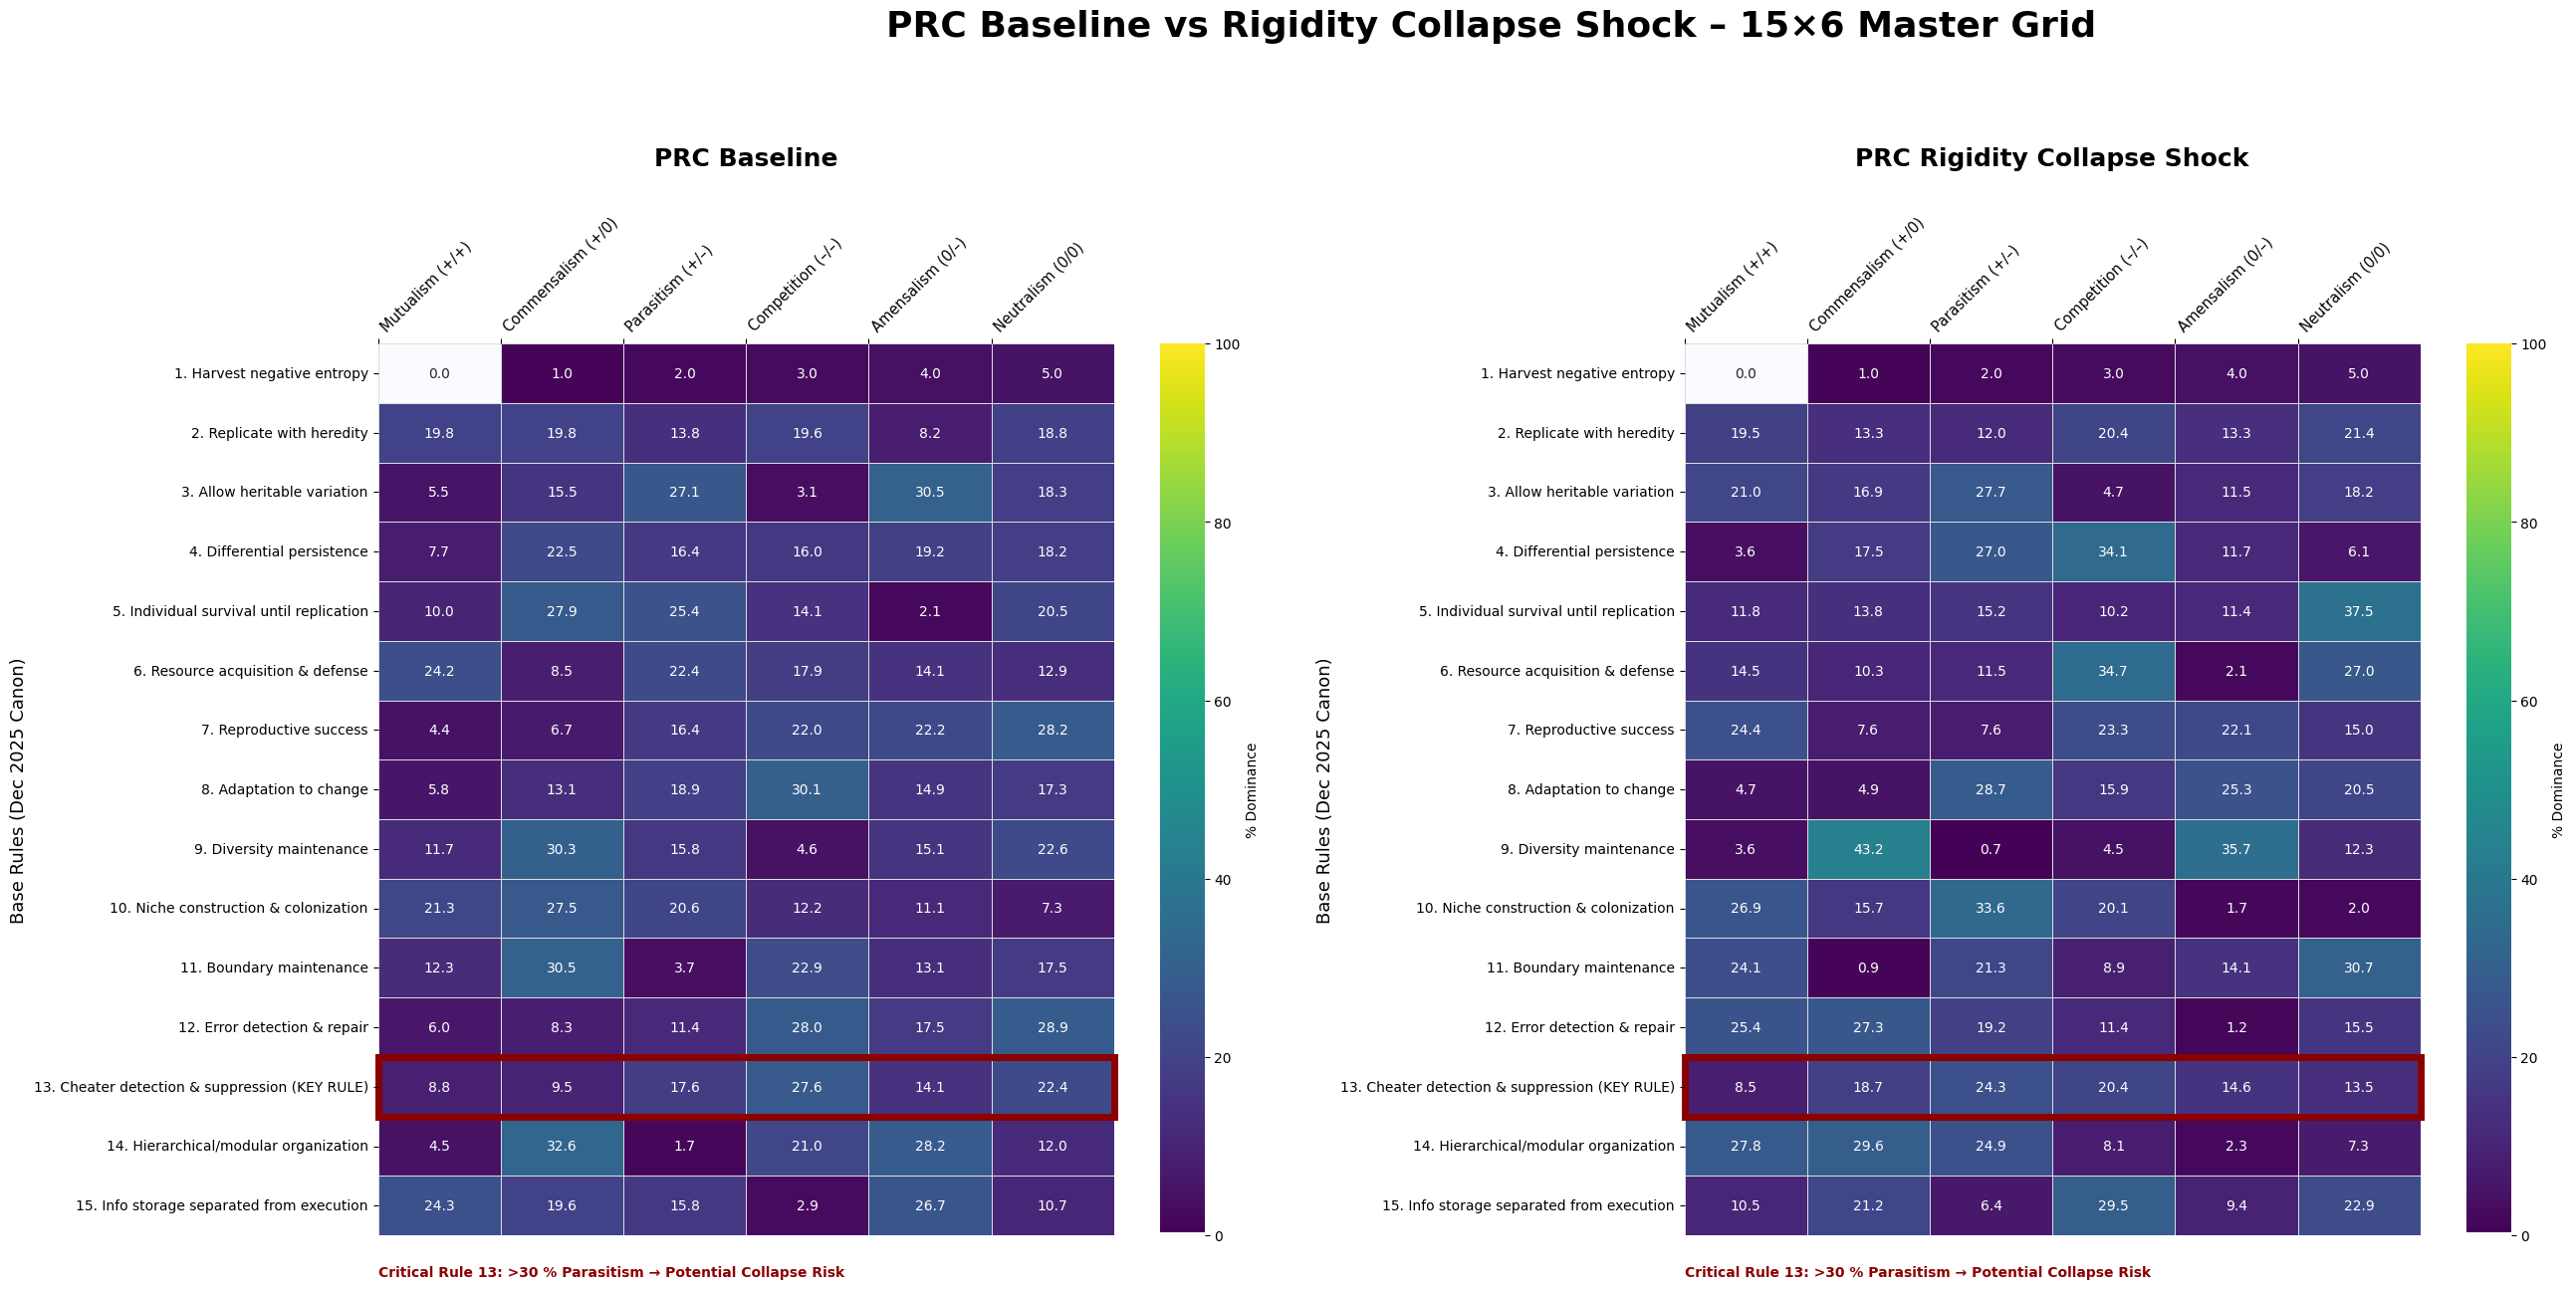

Saved: figures/prc_baseline_vs_rigidity_collapse.png


In [14]:
# === FIG 7.Y – PRC BASELINE vs RIGIDITY COLLAPSE SHOCK – MATCHES FIG. 6.1 LAYOUT ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# CANONICAL LABELS (exact from Fig. 6.1)
rules = [
    "1. Harvest negative entropy", "2. Replicate with heredity", "3. Allow heritable variation",
    "4. Differential persistence", "5. Individual survival until replication", "6. Resource acquisition & defense",
    "7. Reproductive success", "8. Adaptation to change", "9. Diversity maintenance",
    "10. Niche construction & colonization", "11. Boundary maintenance", "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)", "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]
moves = ["Mutualism (+/+)", "Commensalism (+/0)", "Parasitism (+/–)",
         "Competition (–/–)", "Amensalism (0/–)", "Neutralism (0/0)"]

# LOAD & TRIM CSVs (self-contained)
df_baseline = pd.read_csv("matrix_prc_1978_none.csv", header=None).iloc[:15]
df_shock    = pd.read_csv("matrix_prc_1978_rigidity_collapse.csv", header=None).iloc[:15]

df_baseline.index = rules
df_baseline.columns = moves
df_shock.index = rules
df_shock.columns = moves

# COLORMAP & STYLE (exact from Fig. 6.1)
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)
oxford_red = "#8B0000"

# DUAL PLOT – layout from Fig. 6.1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 14), sharey=False)

# Baseline left
sns.heatmap(df_baseline, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax1)
ax1.set_title("PRC Baseline", fontsize=18, fontweight='bold', pad=35)
ax1.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax1.xaxis.set_ticks_position('top')
ax1.set_xticks(np.arange(len(moves)))
ax1.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax1.tick_params(axis='y', labelleft=True, labelsize=10)
ax1.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax1.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Shock right
sns.heatmap(df_shock, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax2)
ax2.set_title("PRC Rigidity Collapse Shock", fontsize=18, fontweight='bold', pad=35)
ax2.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax2.xaxis.set_ticks_position('top')
ax2.set_xticks(np.arange(len(moves)))
ax2.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax2.tick_params(axis='y', which='both', labelleft=True, labelsize=10)
ax2.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax2.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

fig.suptitle("PRC Baseline vs Rigidity Collapse Shock – 15×6 Master Grid",
             fontsize=26, fontweight='bold', y=1.06)
plt.subplots_adjust(top=0.82, wspace=0.42, bottom=0.18, left=0.07, right=0.93)

plt.savefig("figures/prc_baseline_vs_rigidity_collapse.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/prc_baseline_vs_rigidity_collapse.png")